In [4]:
import pandas as pd
import numpy as np

# STEP 1: Dummy Sales Data create pannuren - mess ah vechuruken
data = {
    'Order_ID': [101, 102, 103, 104, 105, 106, 107, 101, 108], # 101 duplicate
    'Date': ['2026-08-01', '2026-08-02', None, '2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07', '2026-08-01', '2026-08-08'],
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Laptop', None, 'Mouse', 'Keyboard', 'Laptop', 'Monitor'],
    'Sales_Amount': [50000, 800, 1200, 52000, 1000, None, 1300, 50000, 15000],
    'Region': ['chennai', 'MADURAI', 'Chennai', 'coimbatore', 'Chennai', 'madurai', 'CHENNAI', 'chennai', 'Coimbatore'] # inconsistent
}

df = pd.DataFrame(data)
print("Original Messy Data:")
print(df)

# Idha Excel ah save pannalam - idhu dhan namma "raw data"
df.to_excel('Raw_Sales_Data.xlsx', index=False)
print("\n✅ Raw_Sales_Data.xlsx file create aagiduchu!")

Original Messy Data:
   Order_ID        Date   Product  Sales_Amount      Region
0       101  2026-08-01    Laptop       50000.0     chennai
1       102  2026-08-02     Mouse         800.0     MADURAI
2       103        None  Keyboard        1200.0     Chennai
3       104  2026-08-04    Laptop       52000.0  coimbatore
4       105  2026-08-05      None        1000.0     Chennai
5       106  2026-08-06     Mouse           NaN     madurai
6       107  2026-08-07  Keyboard        1300.0     CHENNAI
7       101  2026-08-01    Laptop       50000.0     chennai
8       108  2026-08-08   Monitor       15000.0  Coimbatore

✅ Raw_Sales_Data.xlsx file create aagiduchu!


--- READING RAW DATA ---

--- CLEANING STARTED ---
Duplicates Removed. Rows now: 8

--- CLEANED DATA ---
   Order_ID       Date   Product  Sales_Amount      Region
0       101 2026-08-01    Laptop  50000.000000     Chennai
1       102 2026-08-02     Mouse    800.000000     Madurai
2       103 2026-08-01  Keyboard   1200.000000     Chennai
3       104 2026-08-04    Laptop  52000.000000  Coimbatore
4       105 2026-08-05   Unknown   1000.000000     Chennai
5       106 2026-08-06     Mouse  17328.571429     Madurai
6       107 2026-08-07  Keyboard   1300.000000     Chennai
8       108 2026-08-08   Monitor  15000.000000  Coimbatore

--- GENERATING REPORT ---
✅ Chart saved: Sales_Report_Chart.png
✅ Excel Report saved: Cleaned_Report_2026-08-20.xlsx
--- AUTOMATION COMPLETE ---


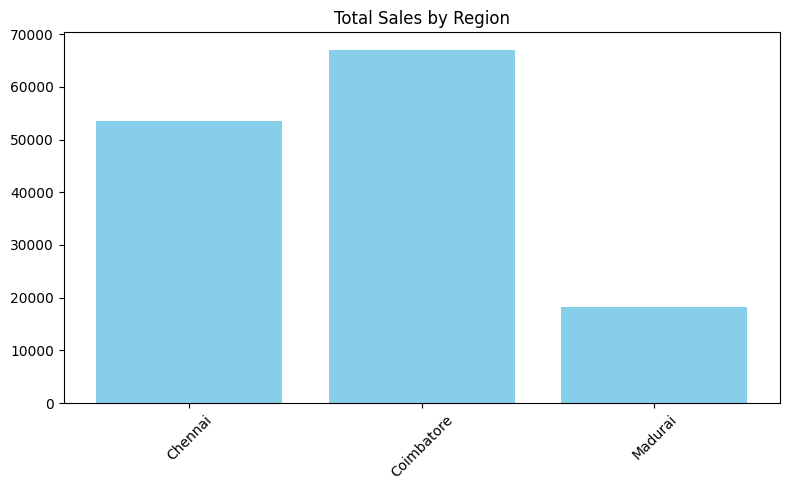

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# STEP 2: DATA CLEANING
print("--- READING RAW DATA ---")
df = pd.read_excel('Raw_Sales_Data.xlsx')

print("\n--- CLEANING STARTED ---")

# 1. Remove Duplicates
df = df.drop_duplicates(subset=['Order_ID'])
print(f"Duplicates Removed. Rows now: {len(df)}")

# 2. Handle Missing Values
df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].fillna(df['Date'].mode()[0])
df['Product'] = df['Product'].fillna('Unknown')
df['Sales_Amount'] = df['Sales_Amount'].fillna(df['Sales_Amount'].mean())

# 3. Fix Inconsistent Data
df['Region'] = df['Region'].str.title()

print("\n--- CLEANED DATA ---")
print(df)

# STEP 3: REPORTING
print("\n--- GENERATING REPORT ---")
summary = df.groupby('Region')['Sales_Amount'].sum().reset_index()
summary = summary.rename(columns={'Sales_Amount': 'Total_Sales'})

# Chart
plt.figure(figsize=(8,5))
plt.bar(summary['Region'], summary['Total_Sales'], color='skyblue')
plt.title('Total Sales by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Sales_Report_Chart.png')
print("✅ Chart saved: Sales_Report_Chart.png")

# Excel Report
report_date = datetime.now().strftime("%Y-%m-%d")
filename = f"Cleaned_Report_{report_date}.xlsx"

with pd.ExcelWriter(filename, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    summary.to_excel(writer, sheet_name='Sales_Summary', index=False)

print(f"✅ Excel Report saved: {filename}")
print("--- AUTOMATION COMPLETE ---")